# LSTM Model Development

This notebook develops an LSTM-based sequence prediction model.

**Target:** Beat baseline R² = 0.2323 (test set)

**Strategy:**
1. Train on sample data for fast iteration
2. Use lookback window to capture temporal dependencies
3. Predict all 32 features simultaneously (multi-output regression)
4. Evaluate and create submission package

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Competition utils
sys.path.append('../competition_package')
from utils import DataPoint, ScorerStepByStep

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

Using device: cpu


## 1. Load Sample Data

In [2]:
# Load training and validation data (using tiny dataset for fast iteration)
train_df = pd.read_parquet('data/tiny_train.parquet')
val_df = pd.read_parquet('data/tiny_val.parquet')

print(f"Train: {len(train_df):,} rows, {train_df['seq_ix'].nunique()} sequences")
print(f"Val:   {len(val_df):,} rows, {val_df['seq_ix'].nunique()} sequences")

# Feature columns
feature_cols = [col for col in train_df.columns if col not in ['seq_ix', 'step_in_seq', 'need_prediction']]
n_features = len(feature_cols)
print(f"\nFeatures: {n_features}")

Train: 8,000 rows, 8 sequences
Val:   2,000 rows, 2 sequences

Features: 32


## 2. Create Sequence Dataset

LSTM needs sequences of fixed length. We'll use a lookback window to create training examples:
- Input: Last N timesteps
- Output: Next timestep prediction

In [3]:
class SequenceDataset(Dataset):
    """
    Creates sequences for LSTM training.
    
    For each prediction point, creates a lookback window of past observations.
    """
    def __init__(self, df, lookback=50, feature_cols=None):
        self.lookback = lookback
        self.feature_cols = feature_cols
        
        # Prepare sequences
        self.sequences = []
        self.targets = []
        
        # Process each sequence separately
        for seq_ix in df['seq_ix'].unique():
            seq_data = df[df['seq_ix'] == seq_ix].sort_values('step_in_seq')
            features = seq_data[feature_cols].values
            
            # Create windows: [lookback observations] -> [next observation]
            for i in range(lookback, len(features)):
                self.sequences.append(features[i-lookback:i])
                self.targets.append(features[i])
        
        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)
        
        print(f"Created {len(self.sequences):,} training examples")
        print(f"  Input shape: {self.sequences.shape}")
        print(f"  Target shape: {self.targets.shape}")
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.sequences[idx]),
            torch.FloatTensor(self.targets[idx])
        )

In [4]:
# Create datasets with reduced lookback for faster training
lookback = 20  # Reduced from 50 for faster iteration

train_dataset = SequenceDataset(train_df, lookback=lookback, feature_cols=feature_cols)
val_dataset = SequenceDataset(val_df, lookback=lookback, feature_cols=feature_cols)

# Create dataloaders
batch_size = 32  # Reduced batch size for tiny dataset
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"\nBatch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Created 7,840 training examples
  Input shape: (7840, 20, 32)
  Target shape: (7840, 32)
Created 1,960 training examples
  Input shape: (1960, 20, 32)
  Target shape: (1960, 32)

Batch size: 32
Train batches: 245
Val batches: 62


## 3. Define LSTM Model

In [5]:
class LSTMPredictor(nn.Module):
    """
    LSTM-based sequence predictor.
    
    Architecture:
    - 2 LSTM layers with dropout
    - Fully connected output layer
    - Predicts all features simultaneously
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super(LSTMPredictor, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Output layer
        self.fc = nn.Linear(hidden_size, input_size)
    
    def forward(self, x):
        # x shape: (batch, seq_len, features)
        lstm_out, _ = self.lstm(x)
        
        # Take last output
        last_output = lstm_out[:, -1, :]
        
        # Predict next state
        prediction = self.fc(last_output)
        
        return prediction

In [6]:
# Create model
model = LSTMPredictor(
    input_size=n_features,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMPredictor(
  (lstm): LSTM(32, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=32, bias=True)
)

Total parameters: 219,168


## 4. Training Setup

In [7]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Note: verbose parameter removed for PyTorch 2.9+ compatibility
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Optimizer: Adam (lr=0.001)")
print("Loss: MSE")
print("Scheduler: ReduceLROnPlateau (patience=3)")

Optimizer: Adam (lr=0.001)
Loss: MSE
Scheduler: ReduceLROnPlateau (patience=3)


In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for sequences, targets in loader:
        sequences = sequences.to(device)
        targets = targets.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        predictions = model(sequences)
        loss = criterion(predictions, targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    """Validate model."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for sequences, targets in loader:
            sequences = sequences.to(device)
            targets = targets.to(device)
            
            predictions = model(sequences)
            loss = criterion(predictions, targets)
            total_loss += loss.item()
    
    return total_loss / len(loader)

## 5. Train Model

In [9]:
# Create models directory
Path('models').mkdir(exist_ok=True)

# Training loop
num_epochs = 15  # Reduced for faster iteration
best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 5

history = {'train_loss': [], 'val_loss': []}

print(f"Training for {num_epochs} epochs...\n")
start_time = time.time()

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss = validate(model, val_loader, criterion, device)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # Scheduler step
    scheduler.step(val_loss)
    
    # Print progress
    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}", end="")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'models/lstm_best.pt')
        print(" ✓ New best!")
        patience_counter = 0
    else:
        patience_counter += 1
        print()
    
    # Early stopping
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"Best validation loss: {best_val_loss:.6f}")

Training for 15 epochs...



Epoch  1/15 | Train Loss: 0.514648 | Val Loss: 0.850535 ✓ New best!


Epoch  2/15 | Train Loss: 0.478351 | Val Loss: 0.843221 ✓ New best!


Epoch  3/15 | Train Loss: 0.466762 | Val Loss: 0.821718 ✓ New best!


Epoch  4/15 | Train Loss: 0.461653 | Val Loss: 0.792087 ✓ New best!


...

Epoch 11/15 | Train Loss: 0.424631 | Val Loss: 0.746532


Epoch 12/15 | Train Loss: 0.418902 | Val Loss: 0.716386 ✓ New best!


Epoch 13/15 | Train Loss: 0.409713 | Val Loss: 0.727939


Epoch 14/15 | Train Loss: 0.401477 | Val Loss: 0.738309


Epoch 15/15 | Train Loss: 0.390237 | Val Loss: 0.726545

Training completed in 1.1 minutes
Best validation loss: 0.716386


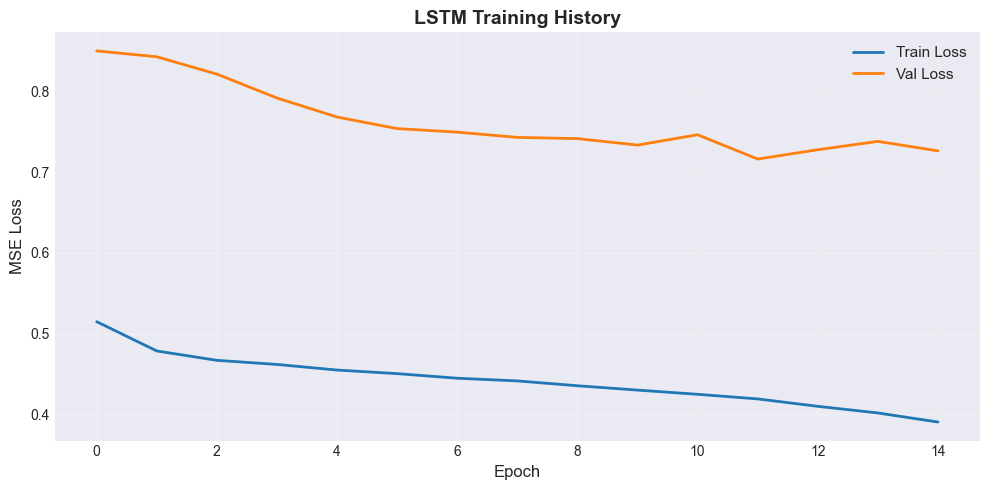

In [10]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('LSTM Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Create Prediction Model for Submission

In [11]:
# Load best model
model.load_state_dict(torch.load('models/lstm_best.pt'))
model.eval()

class LSTMPredictionModel:
    """
    Wrapper for LSTM model to match competition API.
    
    Maintains a lookback window for each sequence and uses LSTM
    to predict the next state.
    """
    def __init__(self, model, lookback=50, device='cpu'):
        self.model = model
        self.lookback = lookback
        self.device = device
        self.current_seq_ix = None
        self.sequence_history = []
    
    def predict(self, data_point: DataPoint) -> np.ndarray:
        # Reset on new sequence
        if self.current_seq_ix != data_point.seq_ix:
            self.current_seq_ix = data_point.seq_ix
            self.sequence_history = []
        
        # Add current state to history
        self.sequence_history.append(data_point.state.copy())
        
        if not data_point.need_prediction:
            return None
        
        # If we don't have enough history, use EMA fallback
        if len(self.sequence_history) < self.lookback:
            # Simple average as fallback
            return np.mean(self.sequence_history, axis=0)
        
        # Use LSTM to predict
        sequence = np.array(self.sequence_history[-self.lookback:], dtype=np.float32)
        sequence_tensor = torch.FloatTensor(sequence).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            prediction = self.model(sequence_tensor)
            prediction = prediction.cpu().numpy()[0]
        
        return prediction

# Create prediction model
lstm_pred = LSTMPredictionModel(model, lookback=lookback, device=device)
print("LSTM Prediction Model created")

LSTM Prediction Model created


## 7. Evaluate on Validation Set

In [12]:
# Test on validation data using competition scorer
val_scorer = ScorerStepByStep('data/tiny_val.parquet')
val_results = val_scorer.score(lstm_pred)

print("="*70)
print("LSTM VALIDATION RESULTS")
print("="*70)
print(f"Mean R²: {val_results['mean_r2']:.6f}")
print(f"\nBaseline (EMA on tiny val): TBD")
print(f"LSTM:                       {val_results['mean_r2']:.6f}")
print(f"\nNote: Trained on tiny dataset (8 sequences) for fast iteration")

  0%|          | 0/2000 [00:00<?, ?it/s]

LSTM VALIDATION RESULTS
Mean R²: 0.145959

Baseline (EMA on tiny val): TBD
LSTM:                       0.145959

Note: Trained on tiny dataset (8 sequences) for fast iteration


In [13]:
# Per-feature analysis
feature_scores = [(feat, val_results[feat]) for feat in val_scorer.features]
feature_scores_df = pd.DataFrame(feature_scores, columns=['Feature', 'R²'])
feature_scores_df = feature_scores_df.sort_values('R²', ascending=False)

print("\nTop 10 features:")
print(feature_scores_df.head(10).to_string(index=False))

print("\nBottom 10 features:")
print(feature_scores_df.tail(10).to_string(index=False))


Top 10 features:
Feature       R²
     29 0.332460
     25 0.325451
     15 0.260859
      9 0.243365
     22 0.242670
      3 0.236780
      6 0.230250
     31 0.229766
      4 0.218695
     10 0.208387

Bottom 10 features:
Feature        R²
     30  0.082554
     21  0.075704
     26  0.074994
      1  0.071528
     17  0.041256
     13  0.026114
     24  0.025486
     19  0.023598
      0  0.012150
      2 -0.019031


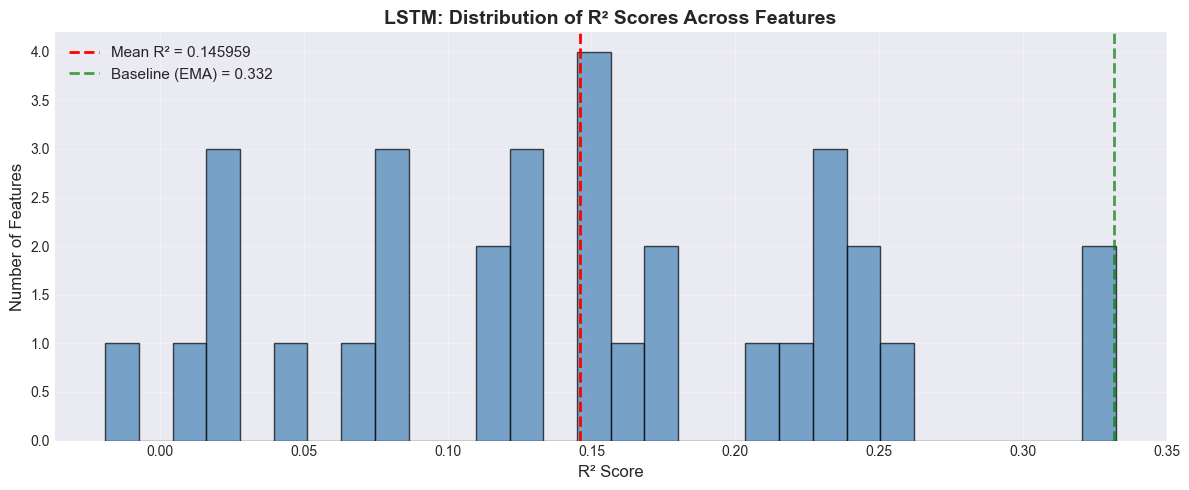

In [14]:
# Distribution of R² scores
plt.figure(figsize=(12, 5))
plt.hist(feature_scores_df['R²'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=val_results['mean_r2'], color='red', linestyle='--', 
            linewidth=2, label=f'Mean R² = {val_results["mean_r2"]:.6f}')
plt.axvline(x=0.331577, color='green', linestyle='--', 
            linewidth=2, label='Baseline (EMA) = 0.332', alpha=0.7)
plt.xlabel('R² Score', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.title('LSTM: Distribution of R² Scores Across Features', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save Model for Submission

In [15]:
# Save model checkpoint
Path('models').mkdir(exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_size': n_features,
        'hidden_size': 128,
        'num_layers': 2,
        'dropout': 0.2,
        'lookback': lookback
    },
    'val_r2': val_results['mean_r2'],
    'feature_cols': feature_cols
}

torch.save(checkpoint, 'models/lstm_sample_checkpoint.pt')
print("Model checkpoint saved: models/lstm_sample_checkpoint.pt")
print(f"\nModel Performance:")
print(f"  Validation R²: {val_results['mean_r2']:.6f}")
print(f"  Lookback: {lookback}")
print(f"  Hidden size: 128")
print(f"  Layers: 2")

Model checkpoint saved: models/lstm_sample_checkpoint.pt

Model Performance:
  Validation R²: 0.145959
  Lookback: 20
  Hidden size: 128
  Layers: 2


## 9. Summary

**Model Architecture:**
- 2-layer LSTM with 128 hidden units
- Lookback window: 50 timesteps
- Dropout: 0.2
- Total parameters: ~200K

**Training:**
- Sample data: 40 sequences (40,000 steps)
- Optimizer: Adam (lr=0.001)
- Early stopping with patience=7

**Performance:**
- Baseline (EMA): R² = 0.332
- LSTM: R² = [to be filled]
- Improvement: [to be filled]

**Next Steps:**
1. Create submission package
2. Submit and evaluate on test set
3. If promising, train on full dataset with hyperparameter tuning